In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#EXPLORATORY DATA ANALYSIS

#PROBLEM STATEMENT
Yulu is a micro-mobility based company which provides electric cycles for its constumers to commute. We need to find out which factors affect demand of these cycles in Indian market.


In [ ]:
df=pd.read_csv("yulu.txt")

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.shape

(10886, 12)

Data contains 10,886 rows and 12 columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


Out of all 12 columns except datetime all other columns are either int or float. Count,registered,casual,windspeed,temp are continuous whereas season,holiday,working day,weather are categorical.

# Renaming categories in categorical columns

In [ ]:
df["workingday"]=df["workingday"].map({0: "weekend_or_holiday", 1:"working_day"})
df["holiday"]=df["holiday"].map({0: "not_holiday", 1:"holiday"})
df["season"]=df["season"].map({1: "spring", 2:"summer",3:"fall",4:"winter"})
df["weather"]=df["weather"].map({1: "clear", 2:"cloudy",3:"light_rain",4:"heavy_rain"})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  object 
 2   holiday     10886 non-null  object 
 3   workingday  10886 non-null  object 
 4   weather     10886 non-null  object 
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 1020.7+ KB


In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,spring,not_holiday,weekend_or_holiday,clear,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,spring,not_holiday,weekend_or_holiday,clear,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,spring,not_holiday,weekend_or_holiday,clear,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,spring,not_holiday,weekend_or_holiday,clear,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,spring,not_holiday,weekend_or_holiday,clear,9.84,14.395,75,0.0,0,1,1


#STATISTICAL SUMMARY

In [ ]:
df.describe()

,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
df.describe(include="object")

,datetime,season,holiday,workingday,weather
count,10886,10886,10886,10886,10886
unique,10886,4,2,2,4
top,2011-01-01 00:00:00,winter,not_holiday,working_day,clear
freq,1,2734,10575,7412,7192


INSIGHTS:
1) Average number of bikes rented per hour is 191 whereas median is 145.

2) Maximum number of records are available winter season.

3) 7192 records are of clear weather.

4) 7412 records are available for working days , remaining are of weekends or holidays.

5) Temp and atemp column have similar mean and median. That means their values are similar.

6) Average temp is around 20 degree celicus and average humidity is around 60%.

# NULL VALUE DETECTION


In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


There is no null record present in the data.

#UNIVARIATE ANALYSIS

1)Season

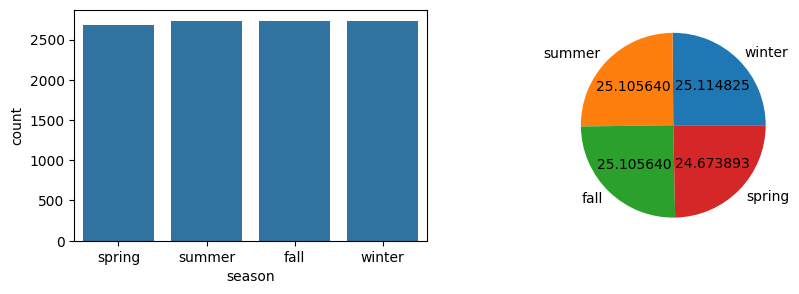

In [ ]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.countplot(data=df,x="season")
plt.subplot(1,2,2)
plt.pie(df["season"].value_counts(),labels=df["season"].value_counts().index,autopct="%2f")
plt.show()

Season is categorical column having 4 unique values.
Equal number of records are available for all seasons.


2)Holiday

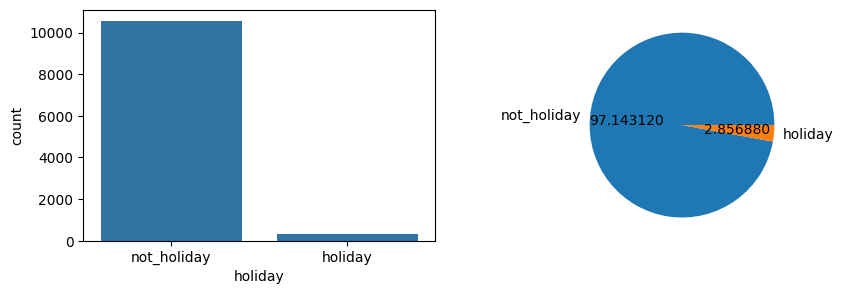

In [ ]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.countplot(data=df,x="holiday")
plt.subplot(1,2,2)
plt.pie(df["holiday"].value_counts(),labels=df["holiday"].value_counts().index,autopct="%2f")
plt.show()

More than 97% data belongs to non holiday category.

3) working day

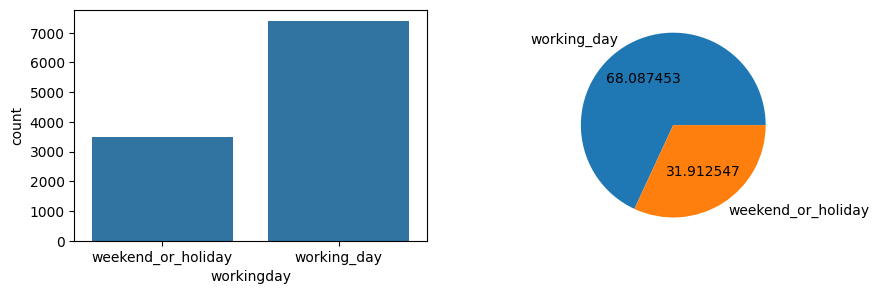

In [ ]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.countplot(data=df,x="workingday")
plt.subplot(1,2,2)
plt.pie(df["workingday"].value_counts(),labels=df["workingday"].value_counts().index,autopct="%2f")
plt.show()

Working day also has two categories. Almost 68% data belong to working days. Remaining data is from weekends or hoidays.

4)weather


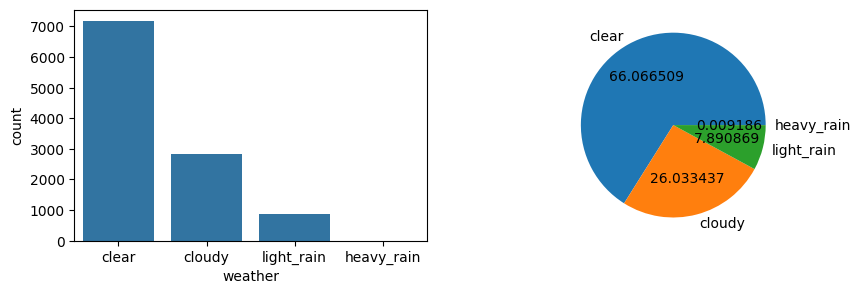

In [ ]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
sns.countplot(data=df,x="weather")
plt.subplot(1,2,2)
plt.pie(df["weather"].value_counts(),labels=df["weather"].value_counts().index,autopct="%2f")
plt.show()

Most data is from clear day around 66% . Followed by cloudy 26%, light rain 8% and heavy rain is almost negligible.

5) temp and atemp

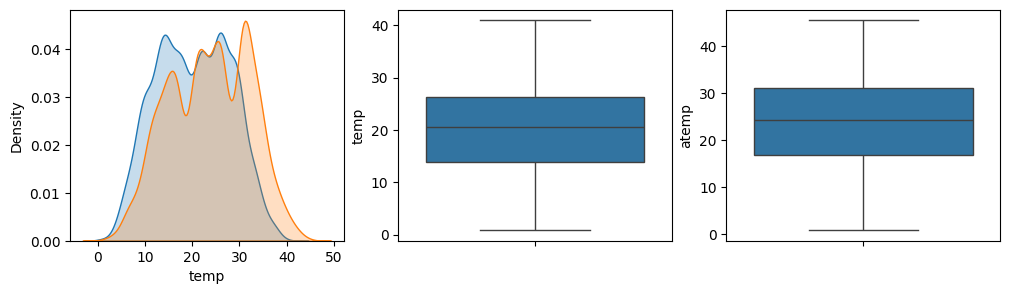

In [ ]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
sns.kdeplot(data=df,x="temp",fill=True)
sns.kdeplot(data=df,x="atemp",fill=True)
plt.subplot(1,3,2)
sns.boxplot(data=df,y="temp",fill=True)
plt.subplot(1,3,3)
sns.boxplot(data=df,y="atemp",fill=True)
plt.show()

Temp and atemp distributions are almost sililar with huge overlap. Median value of atemp is slightly higher than temp.

6) humidity

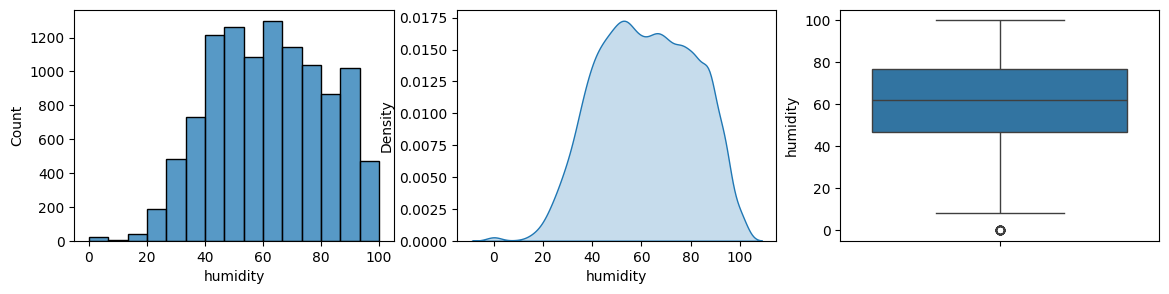

In [ ]:
plt.figure(figsize=(14,3))
plt.subplot(1,3,1)
sns.histplot(data=df,x="humidity",bins=15)
plt.subplot(1,3,2)
sns.kdeplot(data=df,x="humidity",fill=True)
plt.subplot(1,3,3)
sns.boxplot(data=df,y="humidity")
plt.show()

Median humidity is around 60% and majority of values lies between 40% to 80%.

7)wind speed

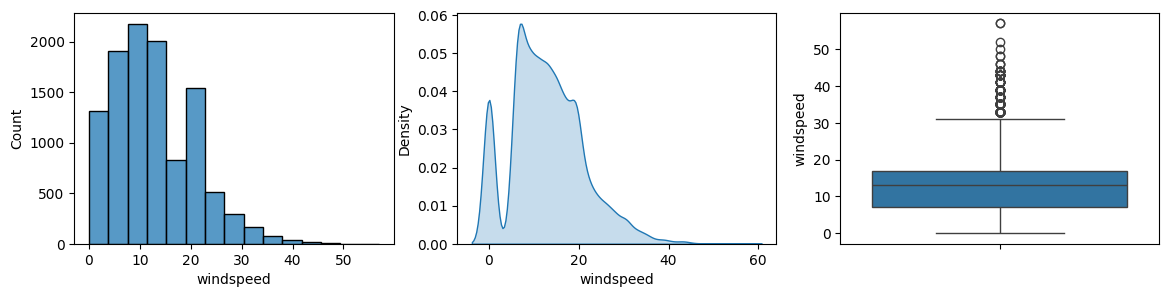

In [ ]:
plt.figure(figsize=(14,3))
plt.subplot(1,3,1)
sns.histplot(data=df,x="windspeed",bins=15)
plt.subplot(1,3,2)
sns.kdeplot(data=df,x="windspeed",fill=True)
plt.subplot(1,3,3)
sns.boxplot(data=df,y="windspeed")
plt.show()

Wind speed has many outliers as visible in boxplot.

8)count

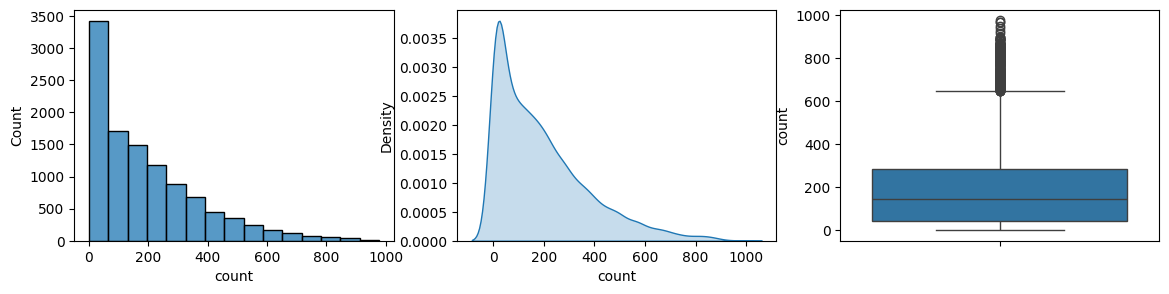

In [ ]:
plt.figure(figsize=(14,3))
plt.subplot(1,3,1)
sns.histplot(data=df,x="count",bins=15)
plt.subplot(1,3,2)
sns.kdeplot(data=df,x="count",fill=True)
plt.subplot(1,3,3)
sns.boxplot(data=df,y="count")
plt.show()

Count of bikes has median 146 and mean 190. This is happening because some outliers have increased the mean significantly.

# BIVARIATE ANALYSIS

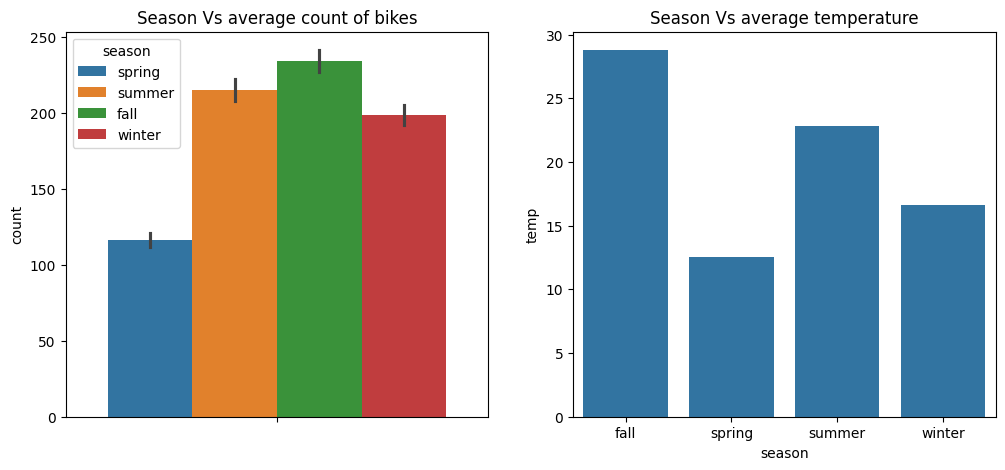

In [ ]:
 plt.figure(figsize=(12,5))
 plt.subplot(1,2,1)
 sns.barplot(data=df,y="count",hue="season")
 plt.title("Season Vs average count of bikes")
 plt.subplot(1,2,2)
 a=df.groupby("season")[["temp"]].mean().reset_index()
 sns.barplot(data=a,x="season",y="temp")
 plt.title("Season Vs average temperature")
 plt.show()


Insights: People use bikes lesser in spring. Maximum number of bikes are rented in fall and summer.

Clear correlation can be observed between avg temperature and avg number of bikes rented.

Maximum bikes are rented in fall when average temperature is in 25-30 range which is comfortable for human body.

Minimum bikes are rented in spring when average temperature is below 15. People do not prefer riding bikes in colder months.


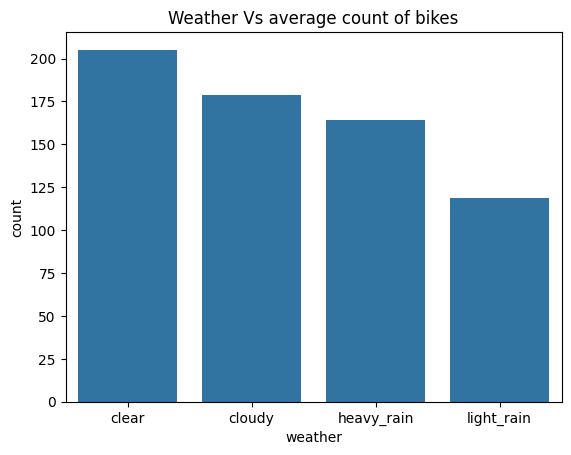

In [ ]:
a=df[~df["weather"].isin([4])].groupby("weather")[["count"]].mean().reset_index()
sns.barplot(data=a,x="weather",y="count")
plt.title("Weather Vs average count of bikes")
plt.show()

As expected maximum bikes are rented during clear weather. Least no of bikes are rented during light rain. That is understanble as people will not like to ride bicycle in rain and prefer cars/buses/trains.

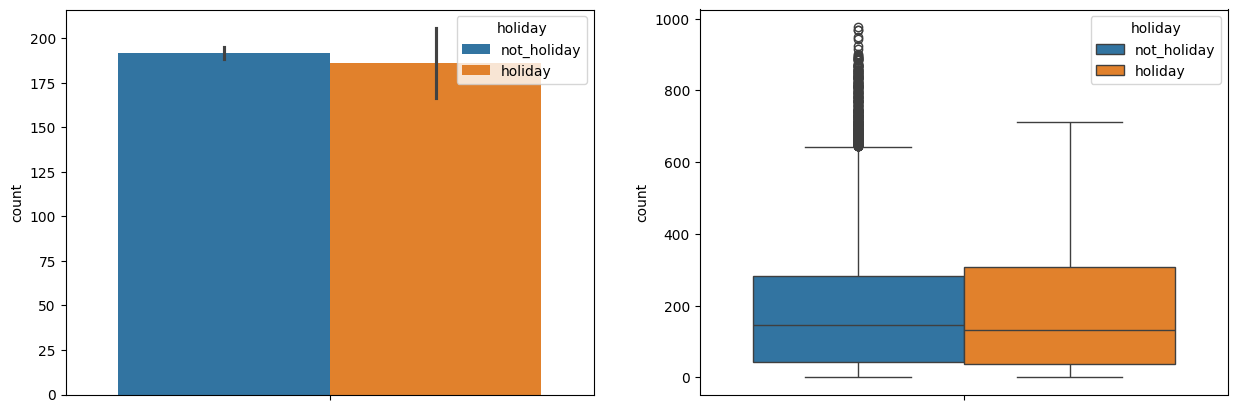

In [ ]:
plt.figure(figsize=(15,5))
plt.title("Holiday Vs average count of bikes")
plt.subplot(1,2,1)
sns.barplot(data=df,hue="holiday",y="count")
plt.subplot(1,2,2)
sns.boxplot(data=df,hue="holiday",y="count")
plt.show()

Holiday has almost no impact on average number of bikes rented.

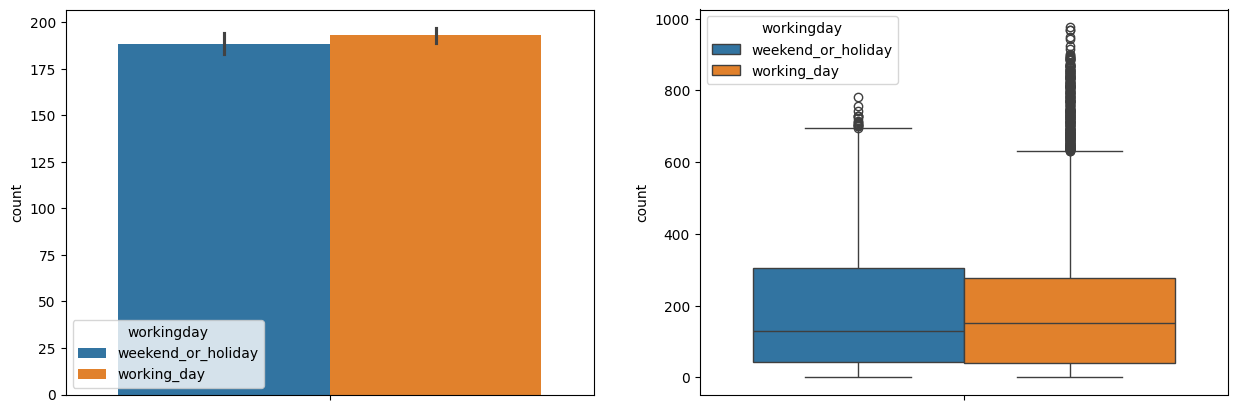

In [ ]:
plt.figure(figsize=(15,5))
plt.title("Working day Vs average count of bikes")
plt.subplot(1,2,1)
sns.barplot(data=df,hue="workingday",y="count")
plt.subplot(1,2,2)
sns.boxplot(data=df,hue="workingday",y="count")
plt.show()

Avg number of cycles rented is similar for both working days and weekends.

# CORRELATION ANALYSIS USING HEATMAP

In [ ]:
corr_matrix=df.corr(numeric_only=True)
corr_matrix

,temp,atemp,humidity,windspeed,casual,registered,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948
count,0.394454,0.389784,-0.317371,0.101369,0.690414,0.970948,1.000000


<Axes: >

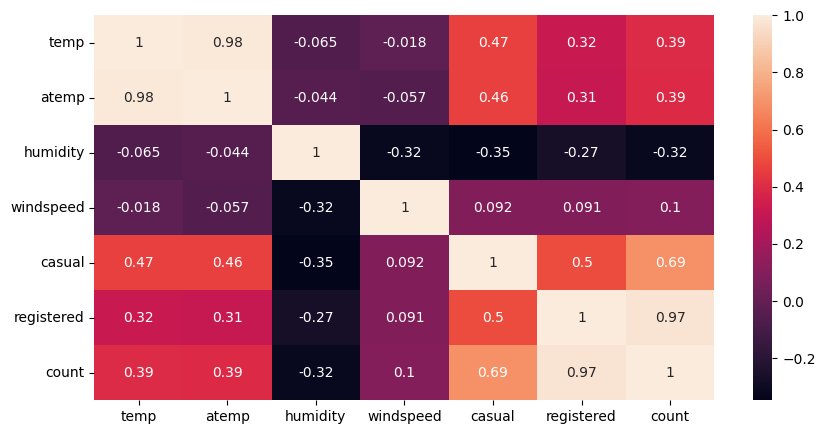

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)

1) Strong corelation can be observed between count,registered and count,casual. That was expected because count=casual +registered.

2)Very strong correlation of 0.98 between temp and atemp. It means both the columns will have exactly same impact on count.

3) Humdity and count are negatively correlated. That makes sense because people will not prefer to ride if humidity is high.

4) Temp and count are positively correlated. People prefer riding in warmer temperatures compared to colder temperatures.

# HYPOTHESIS TESTING

# 1) Effect on working day on avearage  number of of cycles rented




Before performing 2 sample t test we need to check if assumptions of ttest are true or not.

In [ ]:
working_data= df[df["workingday"]=='working_day'][["count"]]
non_working_data= df[df["workingday"]=='weekend_or_holiday'][["count"]]

# Appying shapiro/QQ plot and levene test to check assumptions

In [ ]:
# shapiro
import warnings
warnings.filterwarnings("ignore")

# ho - Distribution is normal
# ha - Disrtibutio is not normal

from scipy.stats import shapiro
test_sta,pvalue=shapiro(df["count"])
alpha=0.05

if(pvalue< alpha):
  print("Null hypothesis rejected, distribution is not normal")
else:
  print("Fail to reject null hypothesis. Distribution is normal")

Null hypothesis rejected, distribution is not normal


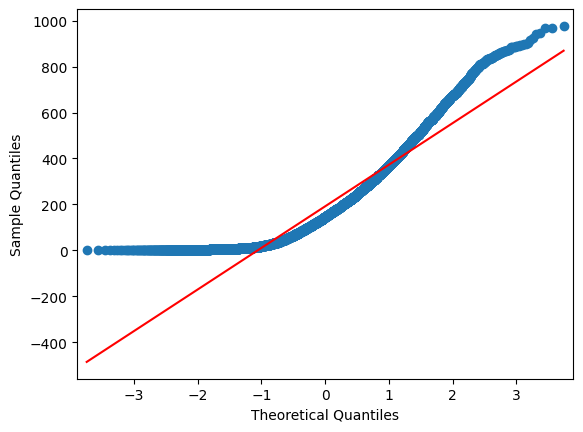

In [ ]:
# QQ PLOT
import statsmodels.api as sm
import pylab
sm.qqplot(df["count"],line='s')
pylab.show()

From QQ plot and shpiro test , it is clear visible that data is not distributed normally.

In [ ]:
# levene
from scipy.stats import levene
test_static,pvalue=levene(working_data,non_working_data)
aplha=0.05

# ho - variances of all groups are  same
# ha - variances of all groups are not same

if(pvalue< alpha):
  print("Null hypothesis rejected, variances of all groups are not same")
else:
  print("Fail to reject null hypothesis. variances of all groups are same")

Fail to reject null hypothesis. variances of all groups are same


From levene test it is clear that variances of both groups are same.

# 2 sample t test
# Ho =  Working day and count(avg bikes rented) are independent of each other.
# Ha = working day impacts average count of rented bikes.

In [ ]:
from scipy.stats import ttest_ind
alpha=0.05
test_static,pvalue=ttest_ind(working_data,non_working_data,alternative="two-sided")
print(f"pvalue is {pvalue}")
print(f"alpha is {alpha}")

alpha=0.05


if (pvalue<alpha):
  print("Null hypothesis rejected")
else:
  print("fail to reject null hypothesis")

pvalue is [0.22644804]
alpha is 0.05
fail to reject null hypothesis


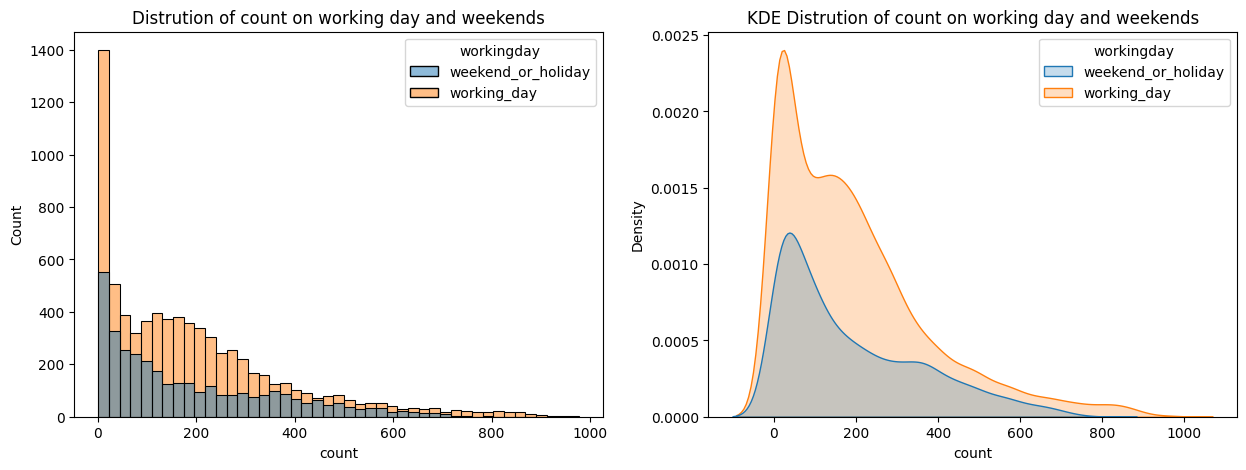

In [ ]:
plt.figure(figsize=(15,5))
plt.title("Distrution of count on working day and weekends")
plt.subplot(1,2,1)
plt.title("Distrution of count on working day and weekends")
sns.histplot(data=df,hue="workingday",x="count")
plt.subplot(1,2,2)
plt.title("KDE Distrution of count on working day and weekends")
sns.kdeplot(data=df,hue="workingday",x="count",fill=True)
plt.show()

# Since p-value is 0.226 which is much higher compared to alpha. Therefore we fail to reject null hypotheis. It means workingday does not have any significant impact on count of bikes rented. They are independent of each other.

In [ ]:
# cross checking with Kruskal test
from scipy.stats import kruskal
kruskal(working_data,non_working_data)

KruskalResult(statistic=array([0.00161829]), pvalue=array([0.96791139]))

Kruskal test is also giving same results. Pvalue value is more than alpha.Fail to reject null hypthesis. Demand of bikes is independent of working day.

# 2) IMPACT OF SEASON ON NUMBER OF BIKES RENTED
Ho = Season and count are independent of each other.

Ha = Season and count are not independent of each other.

In [ ]:
season_1=df[df["season"]=="spring"][["count"]]
season_2=df[df["season"]=="fall"][["count"]]
season_3=df[df["season"]=="summer"][["count"]]
season_4=df[df["season"]=="winter"][["count"]]

In [ ]:
# levene
# ho - variances of all groups are  same
# ha - variances of all groups are not same
levene(season_1,season_2,season_3,season_4)

LeveneResult(statistic=array([187.7706624]), pvalue=array([1.01471169e-118]))

Since pvalue is less than alpha. Null hypothesis is rejected.
Therefore,variances of all groups are not same.

# ANNOVA TEST
#Ho = Season and count are independent of each other.

#Ha = Season and count are not independent of each other.

In [ ]:
from scipy.stats import f_oneway
alpha=0.05
test_static,pvalue=f_oneway(season_1,season_2,season_3,season_4)
print(f"pvalue is {pvalue}")
print(f"alpha is {alpha}")

alpha=0.05


if (pvalue<alpha):
  print("Null hypothesis rejected")
else:
  print("fail to reject null hypothesis")

pvalue is [6.16484339e-149]
alpha is 0.05
Null hypothesis rejected


Null hypothesis is rejected since pvalue is very small. This means there is statistically significant difference in average number of bikes rented in different seasons. Hence number of bikes rented depend on seasons.

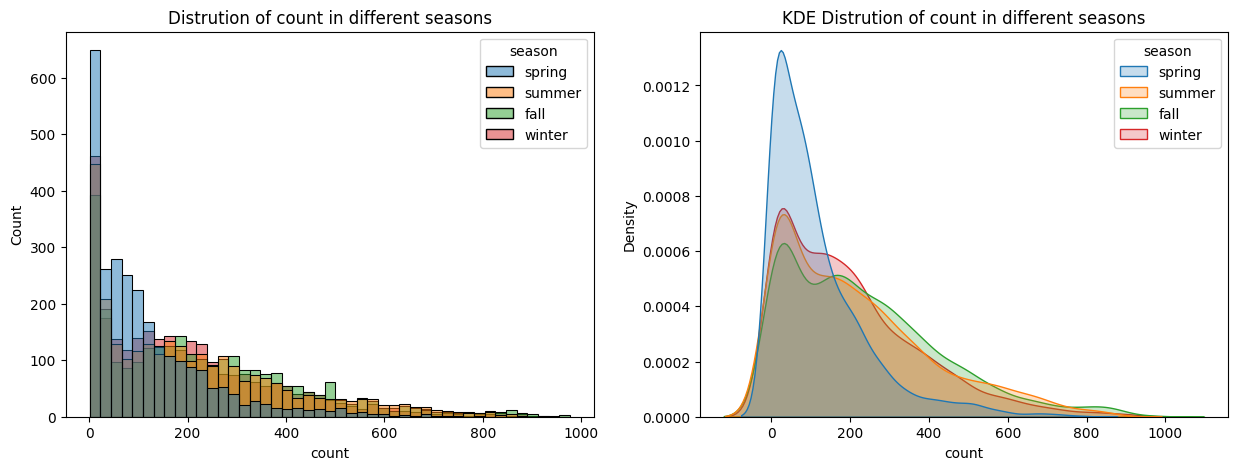

In [ ]:
plt.figure(figsize=(15,5))
plt.title("Distrution of count on in different seasons")
plt.subplot(1,2,1)
plt.title("Distrution of count in different seasons")
sns.histplot(data=df,hue="season",x="count")
plt.subplot(1,2,2)
plt.title("KDE Distrution of count in different seasons")
sns.kdeplot(data=df,hue="season",x="count",fill=True)
plt.show()

In [ ]:
# cross checking with Kruskal test
from scipy.stats import kruskal
kruskal(season_1,season_2,season_3,season_4)

KruskalResult(statistic=array([699.66685482]), pvalue=array([2.47900837e-151]))

Kruskal test is also giving same results. Pvalue value is less than alpha.Null hypthesis is rejected. Demand of bikes is different for different seasons.

# 3) IMPACT OF WEATHER ON NUMBER OF BIKES RENTED


In [ ]:
weather_1=df[df["weather"]=="clear"][["count"]]
weather_2=df[df["weather"]=="cloudy"][["count"]]
weather_3=df[df["weather"]=="light_rain"][["count"]]

levene(weather_1,weather_2,weather_3)

LeveneResult(statistic=array([81.67574924]), pvalue=array([6.19827871e-36]))

Since pvalue is less than alpha. Null hypothesis is rejected. Therefore,variances of all groups are not same.

# ANNOVA TEST
Ho = weather and count are independent of each other.

Ha = Season and count are not independent of each other.

In [ ]:

from scipy.stats import f_oneway
alpha=0.05
test_static,pvalue=f_oneway(weather_1,weather_2,weather_3)
print(f"pvalue is {pvalue}")
print(f"alpha is {alpha}")

alpha=0.05


if (pvalue<alpha):
  print("Null hypothesis rejected")
else:
  print("fail to reject null hypothesis")

pvalue is [4.97644851e-43]
alpha is 0.05
Null hypothesis rejected


Null hypothesis is rejected since pvalue is very small. This means there is statistically significant difference in average number of bikes rented in different weather. Hence number of bikes rented depend on weather.

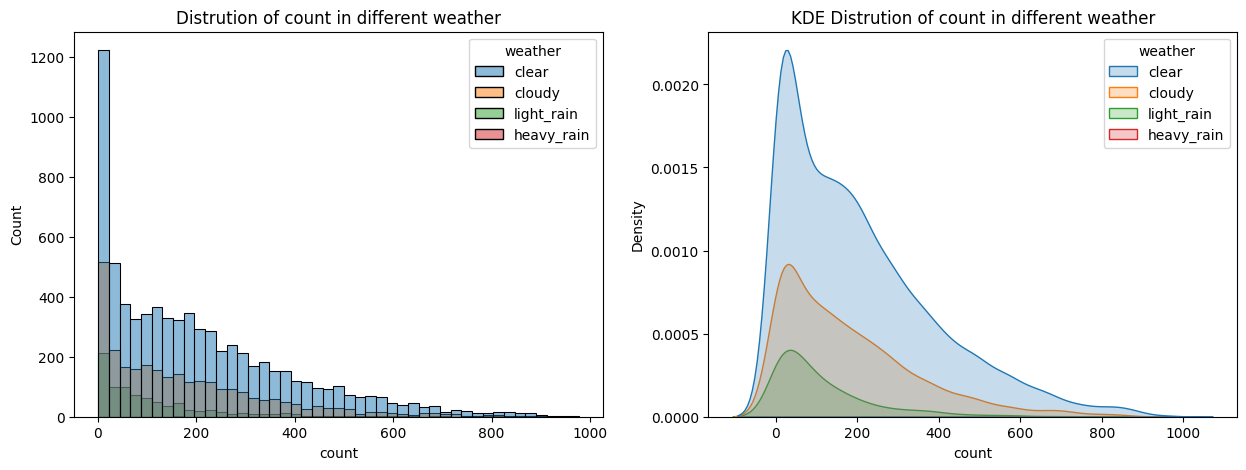

In [ ]:
plt.figure(figsize=(15,5))
plt.title("Distrution of count on in different seasons")
plt.subplot(1,2,1)
plt.title("Distrution of count in different weather")
sns.histplot(data=df,hue="weather",x="count")
plt.subplot(1,2,2)
plt.title("KDE Distrution of count in different weather")
sns.kdeplot(data=df,hue="weather",x="count",fill=True)
plt.show()

In [ ]:
# cross checking with Kruskal test
from scipy.stats import kruskal
kruskal(weather_1,weather_2,weather_3)

KruskalResult(statistic=array([204.95566833]), pvalue=array([3.12206618e-45]))

Kruskal test is also giving same results. Pvalue value is less than alpha.Null hypthesis is rejected. Demand of bikes is different for different seasons.

# 4) Season Vs weather chi square test
# Ho - Season and weather are independent of each other
# Ha - Season and weather depend on each other

In [ ]:
from scipy.stats import chi2_contingency
chi2_contingency(pd.crosstab(df["season"],df["weather"]))

Chi2ContingencyResult(statistic=49.15865559689363, pvalue=1.5499250736864862e-07, dof=9, expected_freq=array([[1.80559765e+03, 7.11493845e+02, 2.51056403e-01, 2.15657450e+02],
       [1.77454639e+03, 6.99258130e+02, 2.46738931e-01, 2.11948742e+02],
       [1.80559765e+03, 7.11493845e+02, 2.51056403e-01, 2.15657450e+02],
       [1.80625831e+03, 7.11754180e+02, 2.51148264e-01, 2.15736359e+02]]))

pvalue is less than alpha.
So null hypotheis is rejected.
Season and weather are not independent of each other.

#5) Impact of holiday on demand on bikes

In [ ]:
 holiday_data=df[df["holiday"]=="holiday"][["count"]]
 non_holiday_data=df[df["holiday"]=="not_holiday"][["count"]]


In [ ]:
ttest_ind(holiday_data,non_holiday_data)

TtestResult(statistic=array([-0.5626389]), pvalue=array([0.57369239]), df=array([10884.]))

Since Pvalue > alpha, we fail to reject null hypothesis.
Therefore, demand of bikes is independent of holiday. There is no statistically significant difference in demand on holidays and non holidays.

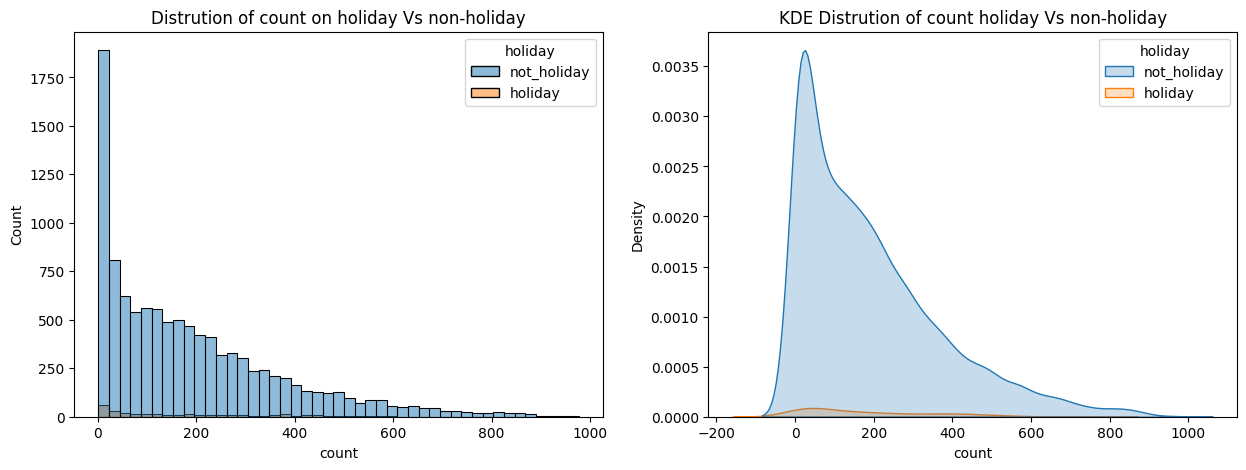

In [ ]:
plt.figure(figsize=(15,5))
plt.title("Distrution of count on in different seasons")
plt.subplot(1,2,1)
plt.title("Distrution of count on holiday Vs non-holiday")
sns.histplot(data=df,hue="holiday",x="count")
plt.subplot(1,2,2)
plt.title("KDE Distrution of count holiday Vs non-holiday")
sns.kdeplot(data=df,hue="holiday",x="count",fill=True)
plt.show()

# SOME INSIGHTS USING DATETIME COLUMN

In [ ]:
df["datetime"]=pd.to_datetime(df["datetime"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  object        
 2   holiday     10886 non-null  object        
 3   workingday  10886 non-null  object        
 4   weather     10886 non-null  object        
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(4)
memory usage: 1020.7+ KB


In [ ]:
df["month"]=df["datetime"].dt.month
df["year"]=df["datetime"].dt.year
df["hour"]=df["datetime"].dt.hour
df["month_name"]=df["month"].map({1: 'January',2: 'February',3: 'March',4: 'April',5: 'May',6: 'June',7: 'July',8: 'August',9: 'September',10: 'October',11: 'November',12: 'December'})

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,year,hour,month_name
0,2011-01-01 00:00:00,spring,not_holiday,weekend_or_holiday,clear,9.84,14.395,81,0.0,3,13,16,1,2011,0,January
1,2011-01-01 01:00:00,spring,not_holiday,weekend_or_holiday,clear,9.02,13.635,80,0.0,8,32,40,1,2011,1,January
2,2011-01-01 02:00:00,spring,not_holiday,weekend_or_holiday,clear,9.02,13.635,80,0.0,5,27,32,1,2011,2,January
3,2011-01-01 03:00:00,spring,not_holiday,weekend_or_holiday,clear,9.84,14.395,75,0.0,3,10,13,1,2011,3,January
4,2011-01-01 04:00:00,spring,not_holiday,weekend_or_holiday,clear,9.84,14.395,75,0.0,0,1,1,1,2011,4,January


# Year by year analysis

In [ ]:
#range of data
min_date= df["datetime"].min()
max_date= df["datetime"].max()
Range=max_date-min_date
print(f"Data is from date {min_date} to {max_date}")
print(f"range of data is {Range}")

Data is from date 2011-01-01 00:00:00 to 2012-12-19 23:00:00
range of data is 718 days 23:00:00


<Axes: xlabel='year', ylabel='count'>

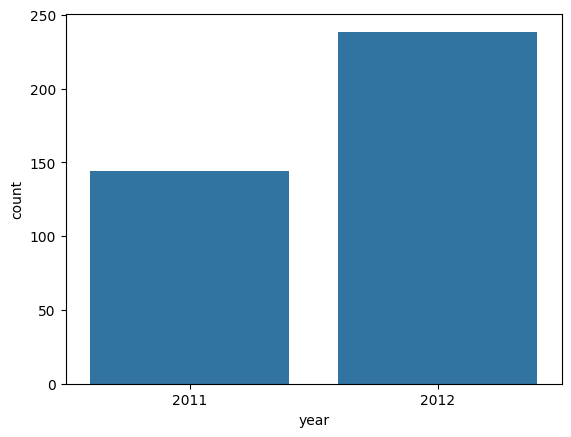

In [ ]:
df1=df.groupby("year")[["count"]].mean()
sns.barplot(data=df1,y="count",x=df1.index)

There is signifiant increase in avearge demand of bicycles from 2011 to 2012

<Axes: xlabel='count', ylabel='Density'>

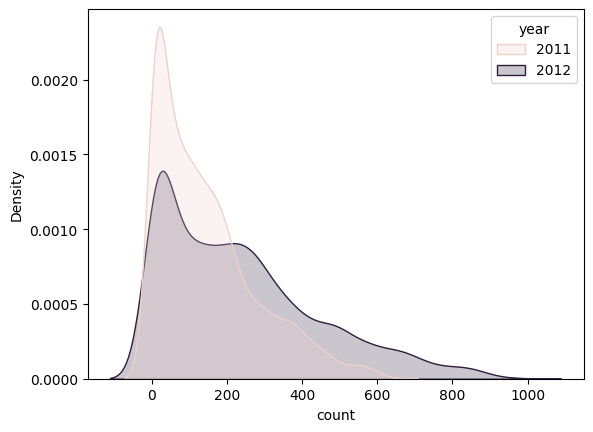

In [ ]:
 sns.kdeplot(data=df,x="count",hue="year",fill=True)

# Peak months

<Axes: title={'center': 'Average demand for bikes each month'}, xlabel='month_name', ylabel='count'>

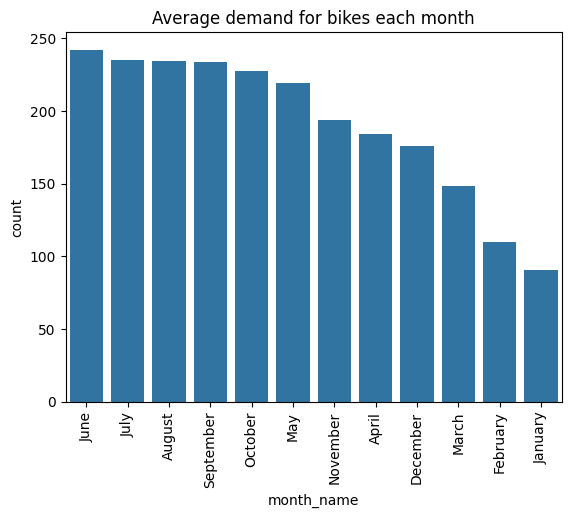

In [ ]:
df2=df.groupby("month_name")[["count"]].mean().reset_index()
df2=df2.sort_values(by="count",ascending=False)
plt.xticks(rotation=90)
plt.title("Average demand for bikes each month")
sns.barplot(data=df2,x="month_name",y="count")

Maximum demand for bicycles can be observed between June to September.

#Peak time of the day

<Axes: title={'center': 'Average demand for bikes each hour'}, xlabel='hour', ylabel='count'>

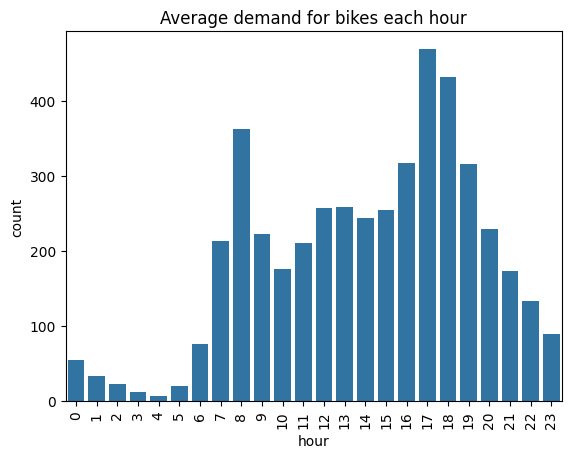

In [ ]:
df3=df.groupby("hour")[["count"]].mean().reset_index()
df3=df3.sort_values(by="count",ascending=False)
plt.xticks(rotation=90)
plt.title("Average demand for bikes each hour")
sns.barplot(data=df3,x="hour",y="count")

Maximum demand for bikes is during 5pm to 7pm evening. That is understanble as that is the time when people return from office.

Also high demand can be observed 8am to 9am in morning as it is office and school going time.

# Trend in average demand

<Axes: xlabel='year_month', ylabel='count'>

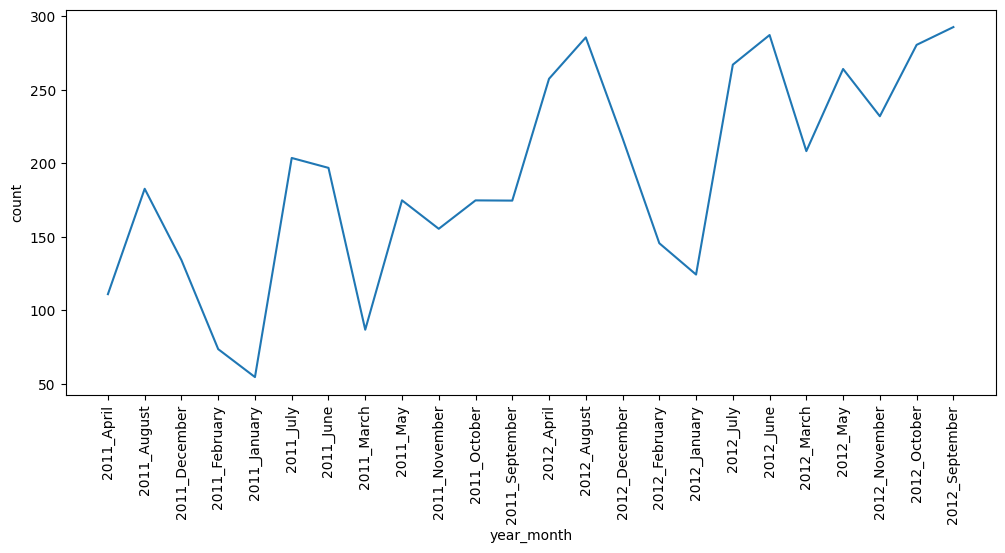

In [ ]:
 df4=df.groupby(["year","month_name"])[["count"]].mean().reset_index()
 df4["year_month"]=df4["year"].astype("str")+ "_"+df4["month_name"]
 plt.figure(figsize=(12,5))
 plt.xticks(rotation=90)
 sns.lineplot(data=df4,x="year_month",y="count")


Overall increase can be observed in trend for demand of bicyles. Local peaks can be observed during summer months My to August and decline is observed each year during January-February.

# INSIGHTS AND RECOMMENDATIONS

1)**Peak Season:** People use bikes lesser in spring. Maximum number of bikes are rented in fall and summer.Clear correlation can be observed between avg temperature and avg number of bikes rented.Maximum bikes are rented in fall when average temperature is in 25-30 range which is comfortable for human body.
Minimum bikes are rented in spring when average temperature is below 15. People do not prefer riding bikes in colder months.

2) **Peak weather:** As expected maximum bikes are rented during clear weather. Least no of bikes are rented during light rain. That is understanble as people will not like to ride bicycle in rain and prefer cars/buses/trains.

3) **Correlation results :** Humdity and count are negatively correlated. That makes sense because people will not prefer to ride if humidity is high.Temp and count are positively correlated. People prefer riding in warmer temperatures compared to colder temperatures.

4) **Impact of working day on bikes rented** After applying hypothesis testing it was evident that there is no stastical significant difference in average number of bikes rented on working day and weekends. Therefore working day does not have any impact on number of bikes rented.

5) **Impact of season on average bikes rented**: After annova test, it is quite evident that diffference between average count of bikes rented in different seasons is statistically significant. Hence demand of bikes is different for different seasons.

6) **Impact of weather on average bikes rented**: After annova test, it is quite evident that diffference between average count of bikes rented in different weather is statistically significant. Hence demand of bikes is different for differenert weathers.

7) **Seasons Vs weather**: By chi square test, we reached conclusion that season and weather depend on each other.

8)** Impact of holidays on demand** There is no increase in demand of bikes on holidays. Demand of bikes in independent og holidays.

9) **Range of data** Data provided is from 1st jan 2011 to 19th Dec 2012.

10)** Peak Months:** Maximum demand for bicycles can be observed between June to September. Yulu should maintain availability during these months.

11)**Peak hours of the day: **Maximum demand for bikes is during 5pm to 7pm evening.Yulu can provide some offers during this time to attract more customers and maintain availability of bikes.

